<font face="Garamond">

<center> <font size="7" color="indigo"> Computational Data Mining – Homework 4
<center> <font size="5" color="indigo"> Project Topic: Geometry of Learning (Curvature, Orthogonality, and Computational Cost in Neural Networks)

<center> <img src="https://upload.wikimedia.org/wikipedia/commons/f/fa/Amirkabir-University-of-Technology-Logo.png" width="200"/>


<center> <font size="4" color="darkblue"> Amirkabir University of Technology – Fall 2025


In [ ]:
import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.dpi": 120,
        "font.family": "serif",
        "font.size": 10
    }
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits, load_breast_cancer

from scipy.optimize import minimize

<font face="Book Antiqua">

# Part 1: Mathematical Analysis (Ill-Conditioned Surfaces)

## Step 1.1 – Implement the algorithms from scratch

In [ ]:
import numpy as np
# Ill-conditioned Hessian matrix
H = np.array([[1.0, 0.0],
              [0.0, 50.0]])
# Quadratic cost function
def cost_func(v):
    return 0.5 * v.T @ H @ v

In [ ]:
H = np.array([[1.0, 0.0],
              [0.0, 50.0]])
H_inv = np.linalg.inv(H)

def cost(v):
    v = np.asarray(v).reshape(2,)
    return 0.5 * v.T @ H @ v

def grad(v):
    v = np.asarray(v).reshape(2,)
    return H @ v

def gradient_descent(x0, lr=0.03, iters=80):
    x = x0.copy()
    path = [x.copy()]
    for _ in range(iters):
        g = grad(x)
        x = x - lr * g
        path.append(x.copy())
    return np.array(path)

def newton(x0, iters=10):
    x = x0.copy()
    path = [x.copy()]
    for _ in range(iters):
        x = x - H_inv @ grad(x)
        path.append(x.copy())
    return np.array(path)

def conjugate_gradient_quadratic(x0, iters=80):
    x = x0.copy()
    r = -grad(x)
    p = r.copy()
    path = [x.copy()]
    for _ in range(iters):
        Ap = H @ p
        denom = p.dot(Ap)
        if abs(denom) < 1e-16:
            break
        alpha = r.dot(r) / denom
        x = x + alpha * p
        r_next = r - alpha * Ap
        if np.linalg.norm(r_next) < 1e-12:
            path.append(x.copy()); break
        beta = r_next.dot(r_next) / r.dot(r)
        p = r_next + beta * p
        r = r_next
        path.append(x.copy())
    return np.array(path)

x0 = np.array([3.0, 2.0])

gd_path = gradient_descent(x0, lr=0.03, iters=80)
newton_path = newton(x0, iters=10)
cg_path = conjugate_gradient_quadratic(x0, iters=80)

print("Start:", x0)
print("GD final:", gd_path[-1], "cost:", cost(gd_path[-1]))
print("Newton final:", newton_path[-1], "cost:", cost(newton_path[-1]))
print("CG final:", cg_path[-1], "cost:", cost(cg_path[-1]))

Start: [3. 2.]
GD final: [2.62337271e-01 1.65436123e-24] cost: 0.03441042181397987
Newton final: [0. 0.] cost: 0.0
CG final: [-4.44089210e-16 -8.27484782e-15] cost: 1.711926269066265e-27


## Step 1.2 – Visualization of Paths

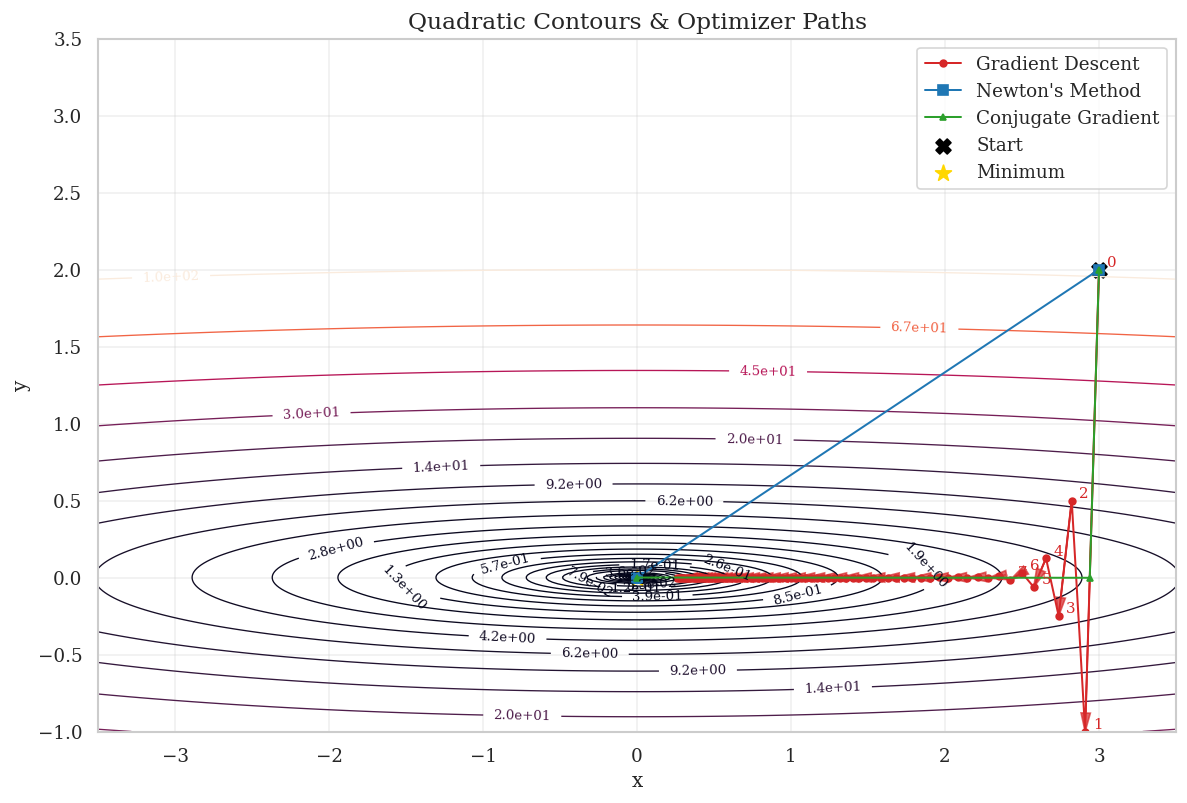

In [ ]:
xlim = (-3.5, 3.5)
ylim = (-1.0, 3.5)
xs = np.linspace(xlim[0], xlim[1], 400)
ys = np.linspace(ylim[0], ylim[1], 400)
X, Y = np.meshgrid(xs, ys)
Z = 0.5 * (H[0,0]*X**2 + H[1,1]*Y**2)

levels = np.logspace(-3, 2, 30)

plt.figure(figsize=(10,8))
CS = plt.contour(X, Y, Z, levels=levels, linewidths=0.8)
plt.clabel(CS, inline=1, fontsize=8, fmt="%.1e")

plt.plot(gd_path[:,0], gd_path[:,1], '-o', markersize=4, linewidth=1.2, label='Gradient Descent', color='#d62728')
plt.plot(newton_path[:,0], newton_path[:,1], '-s', markersize=6, linewidth=1.2, label="Newton's Method", color='#1f77b4')
plt.plot(cg_path[:,0], cg_path[:,1], '-^', markersize=4, linewidth=1.2, label='Conjugate Gradient', color='#2ca02c')

for i in range(0, len(gd_path)-2, 2):
    a = gd_path[i]
    b = gd_path[i+1]
    dx, dy = b - a
    plt.arrow(a[0], a[1], dx, dy, head_width=0.06, head_length=0.12, fc='#d62728', ec='#d62728', length_includes_head=True, alpha=0.7)

for i in range(min(8, len(gd_path))):
    xi, yi = gd_path[i]
    plt.text(xi + 0.05, yi + 0.02, str(i), color='#d62728', fontsize=9)

plt.scatter([x0[0]], [x0[1]], marker='X', s=80, label='Start', color='black')
plt.scatter([0.0], [0.0], marker='*', s=100, label='Minimum', color='gold')

plt.xlim(xlim)
plt.ylim(ylim)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Quadratic Contours & Optimizer Paths', fontsize=14)
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

<font face="Book Antiqua">

# Part 2: Classical Neural Network (Newtonian Space)

## Step 2.1 – Dataset and Model

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

n_samples, input_dim = X.shape
hidden = 5
output_dim = 1

W1 = np.random.randn(input_dim, hidden) * 0.1
b1 = np.zeros((1, hidden))
W2 = np.random.randn(hidden, output_dim) * 0.1
b2 = np.zeros((1, output_dim))

def unpack_params(theta):
    i1 = input_dim * hidden
    i2 = i1 + hidden
    i3 = i2 + hidden * output_dim
    i4 = i3 + output_dim

    W1 = theta[:i1].reshape(input_dim, hidden)
    b1 = theta[i1:i2].reshape(1, hidden)
    W2 = theta[i2:i3].reshape(hidden, output_dim)
    b2 = theta[i3:i4].reshape(1, output_dim)
    return W1, b1, W2, b2

def forward(W1, b1, W2, b2, X):
    H = np.maximum(0, X @ W1 + b1)
    yhat = H @ W2 + b2
    return yhat, H

def loss_grad(theta):
    W1, b1, W2, b2 = unpack_params(theta)
    yhat, H = forward(W1, b1, W2, b2, X)
    loss = np.mean((yhat - y)**2)
    dY = 2*(yhat-y)/n_samples
    gW2 = H.T @ dY
    gb2 = np.sum(dY,axis=0,keepdims=True)
    dH = dY @ W2.T
    dH[H<=0] = 0
    gW1 = X.T @ dH
    gb1 = np.sum(dH,axis=0,keepdims=True)
    grad = np.concatenate([gW1.ravel(), gb1.ravel(),
                           gW2.ravel(), gb2.ravel()])
    return loss, grad

theta0 = np.concatenate([W1.ravel(), b1.ravel(), W2.ravel(), b2.ravel()])

## Step 2.2 – Optimizer Competition

In [ ]:
def train_sgd(theta, lr=0.01, epochs=200):
    times = []
    losses = []
    t0 = time.time()

    for _ in range(epochs):
        loss, grad = loss_grad(theta)
        theta -= lr * grad
        times.append(time.time() - t0)
        losses.append(loss)

    return theta, losses, times

def train_lbfgs(theta0):
    losses = []
    times = []
    t0 = time.time()

    def func(theta):
        loss, grad = loss_grad(theta)
        losses.append(loss)
        times.append(time.time() - t0)
        return loss, grad

    minimize(func, theta0, method='L-BFGS-B', jac=True)
    return losses, times

def train_cg(theta0):
    losses = []
    times = []
    t0 = time.time()

    def func(theta):
        loss, grad = loss_grad(theta)
        losses.append(loss)
        times.append(time.time() - t0)
        return loss, grad

    minimize(func, theta0, method='CG', jac=True, options={'maxiter':200})
    return losses, times

theta_sgd, sgd_losses, sgd_time = train_sgd(theta0.copy())
lbfgs_losses, lbfgs_time = train_lbfgs(theta0.copy())
cg_losses, cg_time = train_cg(theta0.copy())

print("SGD final loss:", sgd_losses[-1], "time:", sgd_time[-1])
print("L-BFGS final loss:", lbfgs_losses[-1], "time:", lbfgs_time[-1])
print("CG final loss:", cg_losses[-1], "time:", cg_time[-1])

SGD final loss: 0.07742119812314341 time: 0.07180666923522949
L-BFGS final loss: 0.0031491365903598416 time: 1.1818702220916748
CG final loss: 0.009234006195592831 time: 0.1375279426574707


## Step 2.3 – Comparison Plot

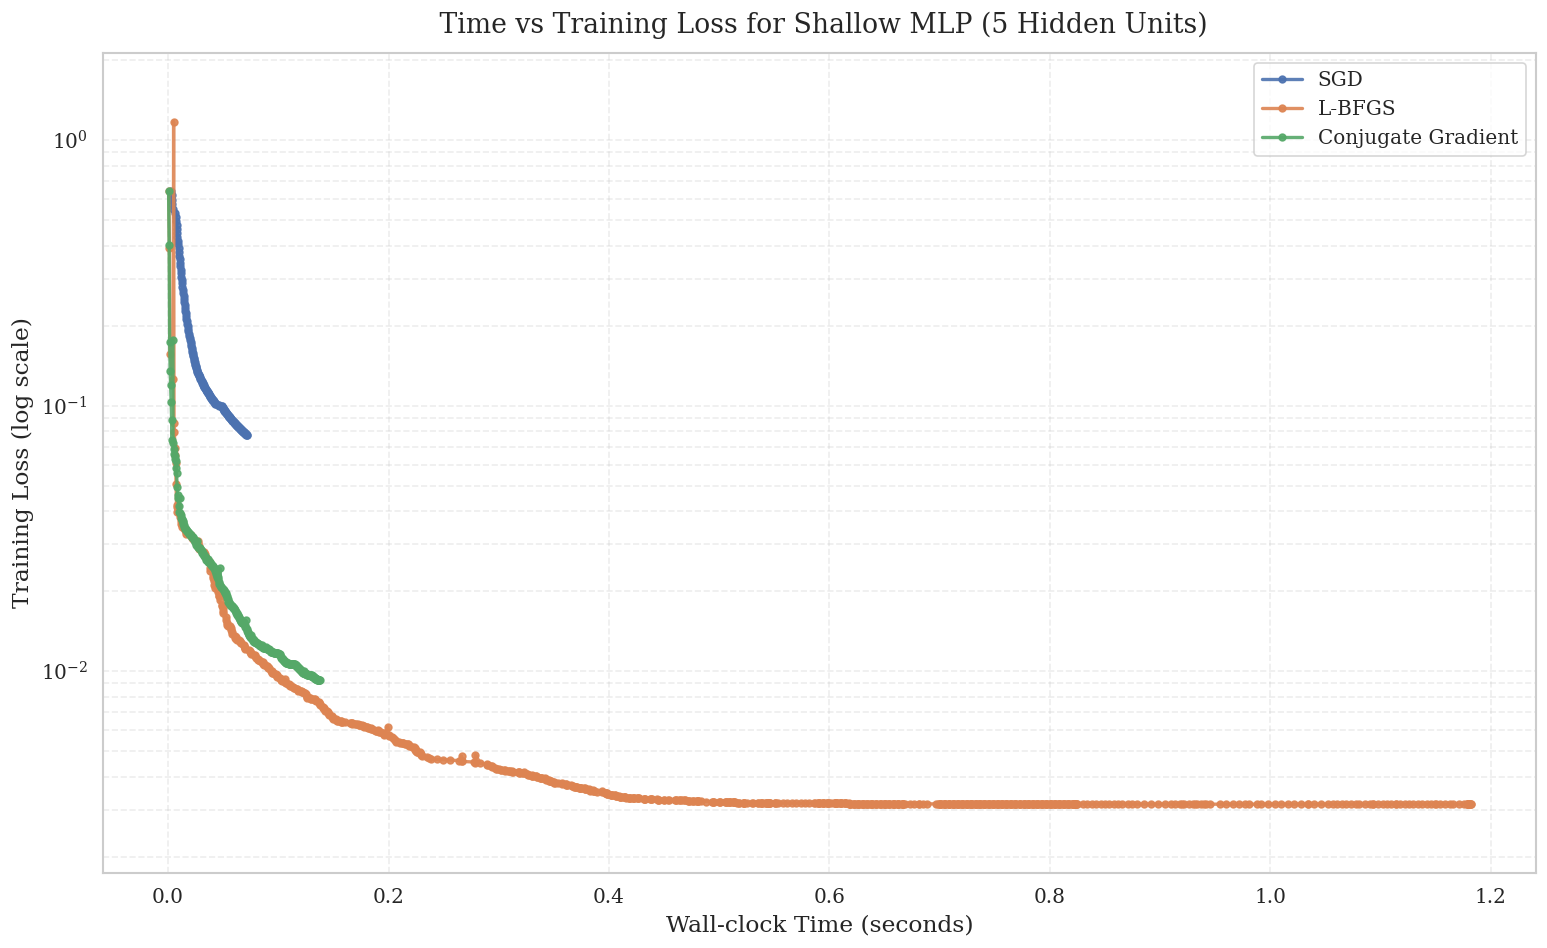

In [ ]:
plt.figure(figsize=(13,8))

plt.semilogy(sgd_time, sgd_losses, '-o', markersize=4, linewidth=2,
             label='SGD', alpha=0.9)
plt.semilogy(lbfgs_time, lbfgs_losses, '-o', markersize=4, linewidth=2,
             label='L-BFGS', alpha=0.9)
plt.semilogy(cg_time, cg_losses, '-o', markersize=4, linewidth=2,
             label='Conjugate Gradient', alpha=0.9)

plt.xlabel("Wall-clock Time (seconds)", fontsize=14)
plt.ylabel("Training Loss (log scale)", fontsize=14)

plt.title(" Time vs Training Loss for Shallow MLP (5 Hidden Units)",
          fontsize=16, pad=12)

plt.grid(True, which='both', linestyle='--', alpha=0.35)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, frameon=True)

plt.margins(x=0.05, y=0.1)
plt.tight_layout()
plt.show()

<font face="Book Antiqua">

# Part 3: Deep Network and the Scalability Trap

## Step 3.1 – Deep Model

In [ ]:
np.random.seed(0)

digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(int)
n_classes = len(np.unique(y))

scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = np.eye(n_classes)[y]

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=1)

n_samples, input_dim = X_train.shape

hidden = 100
sizes = [input_dim, hidden, hidden, hidden, n_classes]

def count_params(sizes):
    total = 0
    for i in range(len(sizes)-1):
        total += sizes[i]*sizes[i+1] + sizes[i+1]
    return total

N = count_params(sizes)
hessian_bytes = N * N * 4
hessian_gb = hessian_bytes / (1024**3)

print("Layer sizes:", sizes)
print(f"Total parameters N = {N:,}")
print(f"Hessian memory (float32): {hessian_bytes:,} bytes ≈ {hessian_gb:.2f} GB\n")

Layer sizes: [64, 100, 100, 100, 10]
Total parameters N = 27,710
Hessian memory (float32): 3,071,376,400 bytes ≈ 2.86 GB



## Step 3.2 – Hessian Size Calculation

In [ ]:
def init_params(sizes, scale=0.02):
    params = []
    for i in range(len(sizes)-1):
        W = np.random.randn(sizes[i], sizes[i+1]) * scale
        b = np.zeros((1, sizes[i+1]))
        params.append((W,b))
    return params

def pack(params):
    parts = []
    for W,b in params:
        parts.append(W.ravel()); parts.append(b.ravel())
    return np.concatenate(parts)

def unpack(theta, sizes):
    params = []
    idx = 0
    for i in range(len(sizes)-1):
        w_size = sizes[i]*sizes[i+1]
        W = theta[idx:idx+w_size].reshape(sizes[i], sizes[i+1]); idx += w_size
        b = theta[idx:idx+sizes[i+1]].reshape(1, sizes[i+1]); idx += sizes[i+1]
        params.append((W,b))
    return params

def forward(params, X):
    A = X
    activations = [A]
    preacts = []
    for W,b in params[:-1]:
        Z = A @ W + b
        preacts.append(Z)
        A = np.maximum(0, Z)
        activations.append(A)
    Wn,bn = params[-1]
    Z = activations[-1] @ Wn + bn
    Zs = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Zs)
    probs = expZ / np.sum(expZ, axis=1, keepdims=True)
    activations.append(probs)
    preacts.append(Z)
    return activations, preacts

def loss_and_grad(theta, X, Y, sizes, reg=1e-4):
    params = unpack(theta, sizes)
    acts, pres = forward(params, X)
    probs = acts[-1]
    m = X.shape[0]
    eps = 1e-12
    loss = -np.sum(Y * np.log(probs + eps)) / m
    for W,b in params:
        loss += 0.5 * reg * np.sum(W*W)
    grads = []
    dA = (probs - Y) / m
    for i in range(len(params)-1, -1, -1):
        A_prev = acts[i]
        W,b = params[i]
        dW = A_prev.T @ dA + reg * W
        db = np.sum(dA, axis=0, keepdims=True)
        grads.insert(0, (dW, db))
        if i>0:
            dA_prev = dA @ W.T
            Z_prev = pres[i-1]
            dA = dA_prev * (Z_prev > 0)
    parts = []
    for dW, db in grads:
        parts.append(dW.ravel()); parts.append(db.ravel())
    grad_vec = np.concatenate(parts)
    return loss, grad_vec

params0 = init_params(sizes, scale=0.05)
theta0 = pack(params0)

def train_sgd(theta, X, Y, sizes, lr=0.01, batch=64, epochs=20):
    theta = theta.copy()
    losses = []; times = []
    t0 = time.time()
    n = X.shape[0]
    for ep in range(epochs):
        idx = np.random.permutation(n)
        Xs = X[idx]; Ys = Y[idx]
        for i in range(0, n, batch):
            xb = Xs[i:i+batch]; yb = Ys[i:i+batch]
            _, grad = loss_and_grad(theta, xb, yb, sizes)
            theta -= lr * grad
        loss_full, _ = loss_and_grad(theta, X, Y, sizes)
        losses.append(loss_full); times.append(time.time()-t0)
    return theta, losses, times

def train_adam(theta, X, Y, sizes, lr=0.001, batch=64, epochs=20):
    theta = theta.copy()
    m = np.zeros_like(theta); v = np.zeros_like(theta)
    losses=[]; times=[]
    t0 = time.time(); t=0
    n = X.shape[0]
    for ep in range(epochs):
        idx = np.random.permutation(n)
        Xs = X[idx]; Ys = Y[idx]
        for i in range(0, n, batch):
            t += 1
            xb = Xs[i:i+batch]; yb = Ys[i:i+batch]
            _, grad = loss_and_grad(theta, xb, yb, sizes)
            m = 0.9*m + 0.1*grad
            v = 0.999*v + 0.001*(grad*grad)
            m_hat = m/(1-0.9**t); v_hat = v/(1-0.999**t)
            theta -= lr * m_hat / (np.sqrt(v_hat) + 1e-8)
        loss_full, _ = loss_and_grad(theta, X, Y, sizes)
        losses.append(loss_full); times.append(time.time()-t0)
    return theta, losses, times

print("Training (SGD vs Adam) — short demo...")
theta_init = theta0.copy()
theta_sgd, sgd_losses, sgd_times = train_sgd(theta_init.copy(), X_train, Y_train, sizes, lr=0.01, batch=64, epochs=20)
theta_adam, adam_losses, adam_times = train_adam(theta_init.copy(), X_train, Y_train, sizes, lr=0.001, batch=64, epochs=20)

Training (SGD vs Adam) — short demo...


## Step 3.3 – Alternatives

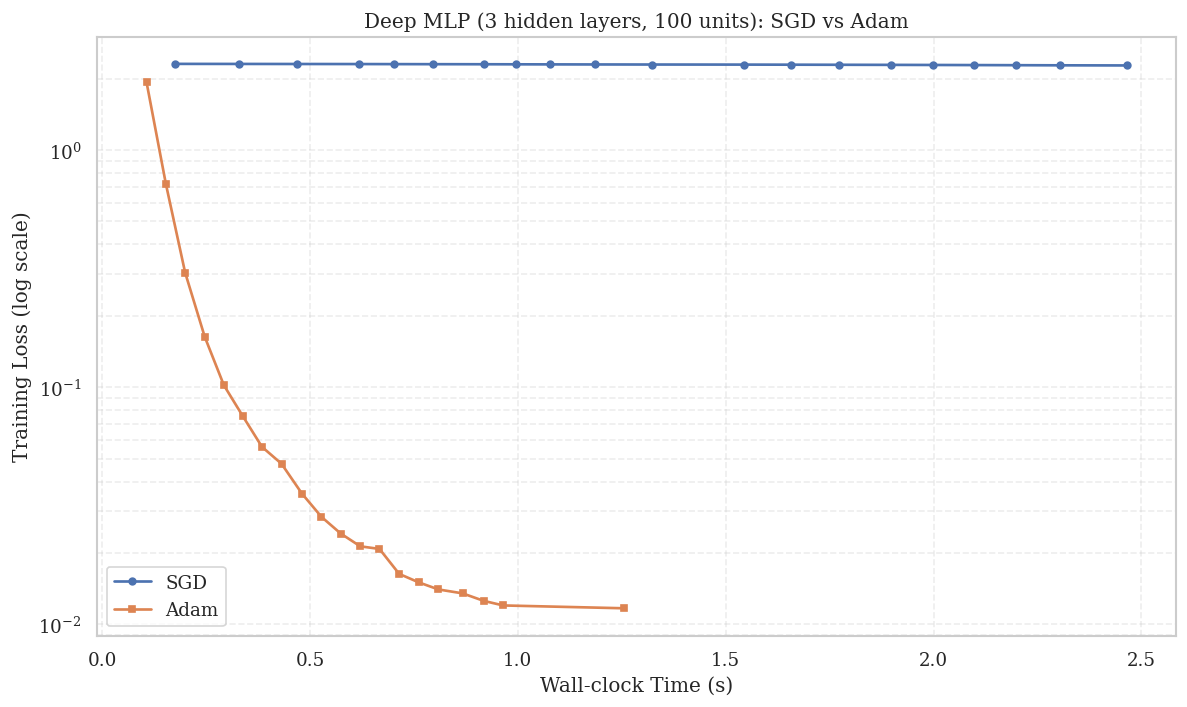


Final losses: SGD 2.271965 (t 2.47s), Adam 0.011693 (t 1.26s)

Hessian storage estimate for N=27,710: ~2.86 GB (float32). Full Newton needs storing/inverting this — infeasible for larger N.)


In [ ]:
plt.figure(figsize=(10,6))
plt.semilogy(sgd_times, sgd_losses, '-o', markersize=4, linewidth=1.6, label='SGD')
plt.semilogy(adam_times, adam_losses, '-s', markersize=4, linewidth=1.6, label='Adam')
plt.xlabel("Wall-clock Time (s)"); plt.ylabel("Training Loss (log scale)")
plt.title("Deep MLP (3 hidden layers, 100 units): SGD vs Adam")
plt.grid(True, which='both', linestyle='--', alpha=0.35)
plt.legend(); plt.tight_layout(); plt.show()

print("\nFinal losses: SGD {:.6f} (t {:.2f}s), Adam {:.6f} (t {:.2f}s)".format(
    sgd_losses[-1], sgd_times[-1], adam_losses[-1], adam_times[-1]))
print(f"\nHessian storage estimate for N={N:,}: ~{hessian_gb:.2f} GB (float32). Full Newton needs storing/inverting this — infeasible for larger N.)")

<font face="Book Antiqua">

# Part 4: Orthogonality and QR (Data Mining Approach)

## Step 4.1 – Correlated Data

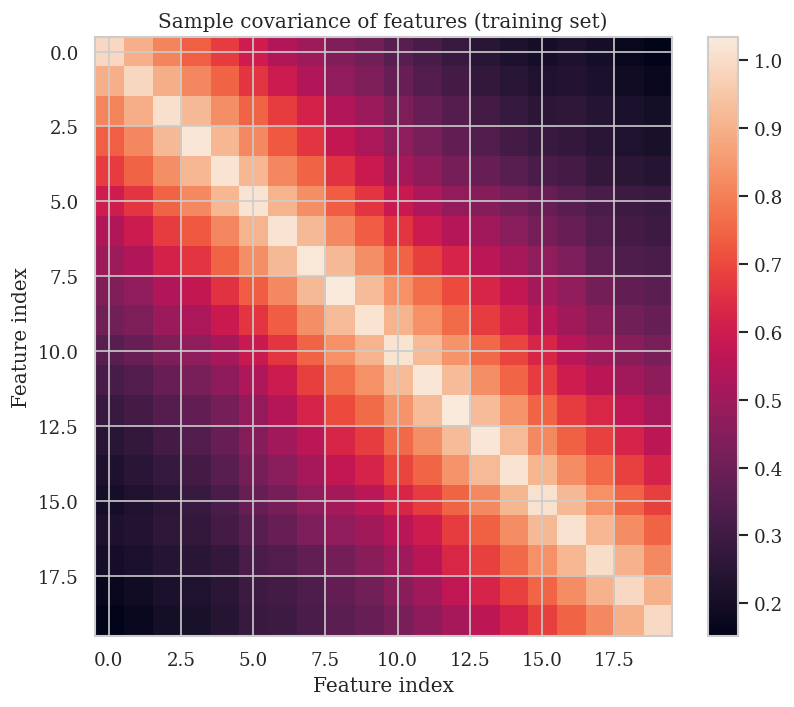

In [ ]:
np.random.seed(1)

n_samples = 2000
n_features = 20
rho = 0.9

inds = np.arange(n_features)
cov = rho ** np.abs(np.subtract.outer(inds, inds))

X = np.random.multivariate_normal(mean=np.zeros(n_features), cov=cov, size=n_samples)
true_w = np.linspace(1, 0.1, n_features)
y = X @ true_w + 0.5 * np.random.randn(n_samples)

X = (X - X.mean(axis=0)) / X.std(axis=0)
y = (y - y.mean()) / y.std()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=2)

sample_cov = np.cov(X_train.T)
plt.figure(figsize=(7,6))
plt.imshow(sample_cov, aspect='auto')
plt.colorbar()
plt.title("Sample covariance of features (training set)")
plt.xlabel("Feature index"); plt.ylabel("Feature index")
plt.tight_layout()
plt.show()

## Step 4.2 – QR Decomposition

In [ ]:
Q, R = np.linalg.qr(X_train, mode='reduced')
print("Shapes: X_train", X_train.shape, "  Q", Q.shape, "  R", R.shape)

def train_linear_sgd(X, y, lr=0.01, batch=64, epochs=100):
    n, d = X.shape
    w = np.zeros(d)
    losses = []; times = []
    t0 = time.time()
    for ep in range(epochs):
        idx = np.random.permutation(n)
        Xs = X[idx]; ys = y[idx]
        for i in range(0, n, batch):
            xb = Xs[i:i+batch]; yb = ys[i:i+batch]
            pred = xb.dot(w)
            err = pred - yb
            grad = (xb.T @ err) / xb.shape[0]
            w -= lr * grad
        loss = np.mean((X.dot(w) - y)**2)
        losses.append(loss); times.append(time.time() - t0)
    return w, losses, times

w_x, losses_x, times_x = train_linear_sgd(X_train, y_train, lr=0.01, batch=64, epochs=80)

w_q, losses_q, times_q = train_linear_sgd(Q, y_train, lr=0.01, batch=64, epochs=80)

Shapes: X_train (1600, 20)   Q (1600, 20)   R (20, 20)


In [ ]:
print("Final MSE: raw X {:.6f}; orthogonalized Q {:.6f}".format(losses_x[-1], losses_q[-1]))

Final MSE: raw X 0.003463; orthogonalized Q 0.995460


## Step 4.3 – Impact on Gradient Descent

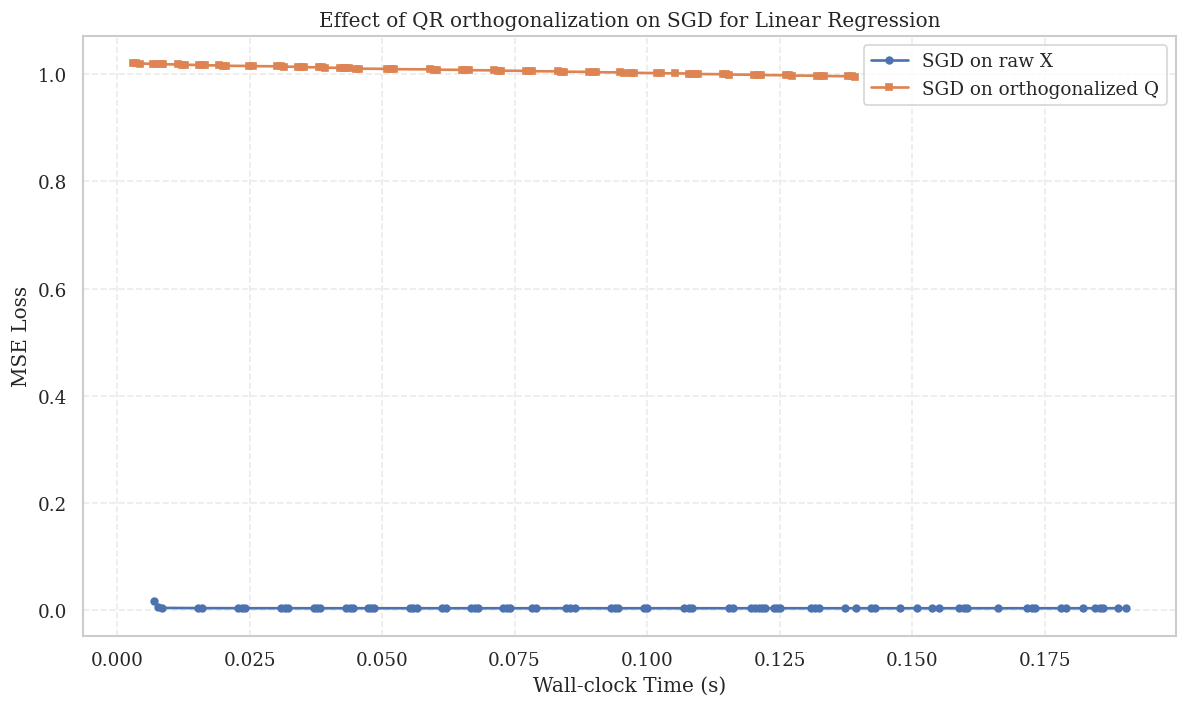

In [ ]:
t_max = max(times_x[-1], times_q[-1])
plt.figure(figsize=(10,6))
plt.plot(times_x, losses_x, '-o', markersize=4, linewidth=1.6, label='SGD on raw X')
plt.plot(times_q, losses_q, '-s', markersize=4, linewidth=1.6, label='SGD on orthogonalized Q')
plt.xlabel("Wall-clock Time (s)"); plt.ylabel("MSE Loss")
plt.title("Effect of QR orthogonalization on SGD for Linear Regression")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(); plt.tight_layout(); plt.show()